以下是逐步运行代码并可视化每一步结果的完整流程。每一步都包含代码和可视化展示的部分。

---

## 第一步：导入必要的库并设置



In [1]:
# 导入必要的库
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, GATConv, global_mean_pool
from torch_geometric.data import Data, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, f1_score
import random
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import networkx as nx  # 添加这个缺失的库

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']  # 指定默认字体为黑体
plt.rcParams['axes.unicode_minus'] = False  # 解决保存图像是负号显示异常的问题

# 设置随机种子以确保可重复性
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)



**可视化展示**：此步骤不涉及可视化。

---

## 第二步：生成模拟数据



In [2]:
def generate_synthetic_urban_data(num_buildings=500, num_blocks=50):
    """生成模拟城市形态数据"""
    # 建筑物特征
    buildings = pd.DataFrame({
        'id': range(num_buildings),
        'height': np.random.normal(20, 10, num_buildings),  # 建筑高度（米）
        'area': np.random.gamma(5, 100, num_buildings),     # 建筑面积（平方米）
        'age': np.random.normal(30, 20, num_buildings),     # 建筑年龄（年）
        'block_id': np.random.randint(0, num_blocks, num_buildings),  # 所属街区ID
        'distance_to_center': np.random.gamma(5, 1000, num_buildings),  # 到市中心距离（米）
        'building_type': np.random.choice([0, 1, 2, 3], num_buildings, p=[0.6, 0.25, 0.1, 0.05])  # 建筑类型
    })

    # 添加一些相关性：距离市中心越远，建筑高度越低
    buildings['height'] = buildings['height'] - buildings['distance_to_center'] * 0.005
    buildings['height'] = np.maximum(buildings['height'], 3)  # 确保最小高度为3米

    # 街区特征
    blocks = pd.DataFrame({
        'id': range(num_blocks),
        'connectivity': np.random.uniform(0.1, 0.9, num_blocks),  # 街区连接性
        'street_width': np.random.normal(12, 3, num_blocks),     # 平均街道宽度（米）
        'intersection_density': np.random.gamma(5, 2, num_blocks),  # 交叉口密度
        'distance_to_center': np.random.gamma(4, 800, num_blocks),  # 到市中心距离（米）
        'population_density': np.random.gamma(5, 2000, num_blocks),  # 人口密度（人/平方公里）
        'function_mix': np.random.uniform(0.1, 0.9, num_blocks)     # 功能混合度
    })

    # 添加相关性：到中心距离与功能混合度负相关，与人口密度负相关
    blocks['function_mix'] = blocks['function_mix'] - blocks['distance_to_center'] * 0.0002
    blocks['function_mix'] = np.maximum(np.minimum(blocks['function_mix'], 0.95), 0.05)  # 限制在[0.05, 0.95]范围内
    blocks['population_density'] = blocks['population_density'] - blocks['distance_to_center'] * 0.8
    blocks['population_density'] = np.maximum(blocks['population_density'], 500)  # 确保最小人口密度

    # 根据城市功能进行分类：0-主要住宅区, 1-商业区, 2-工业区, 3-混合区
    blocks['urban_function'] = np.zeros(num_blocks, dtype=int)
    for i in range(num_blocks):
        block_buildings = buildings[buildings['block_id'] == i]
        building_types = block_buildings['building_type'].value_counts(normalize=True).to_dict()
        for t in [0, 1, 2, 3]:
            if t not in building_types:
                building_types[t] = 0
        if building_types[0] > 0.7:
            blocks.loc[i, 'urban_function'] = 0
        elif building_types[1] > 0.5:
            blocks.loc[i, 'urban_function'] = 1
        elif building_types[2] > 0.3:
            blocks.loc[i, 'urban_function'] = 2
        else:
            blocks.loc[i, 'urban_function'] = 3

    # 添加一些噪声，使得分类更具挑战性
    noise_indices = np.random.choice(num_blocks, size=int(num_blocks * 0.1), replace=False)
    blocks.loc[noise_indices, 'urban_function'] = np.random.randint(0, 4, len(noise_indices))

    return buildings, blocks

# 生成数据
buildings, blocks = generate_synthetic_urban_data(num_buildings=500, num_blocks=50)



**可视化展示**：



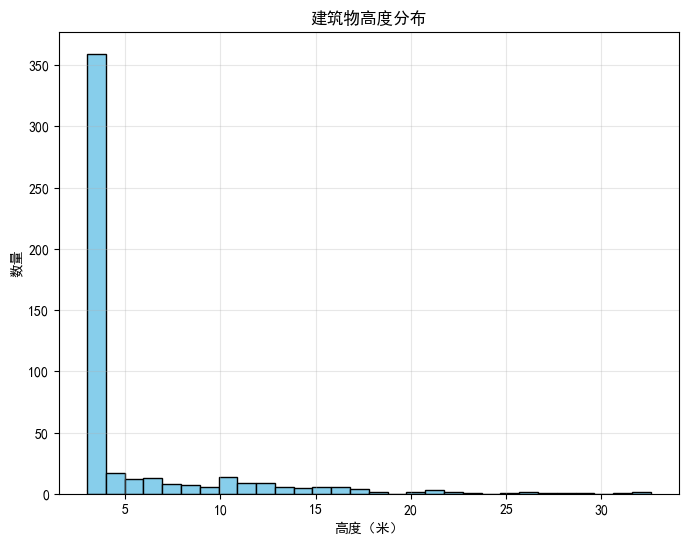

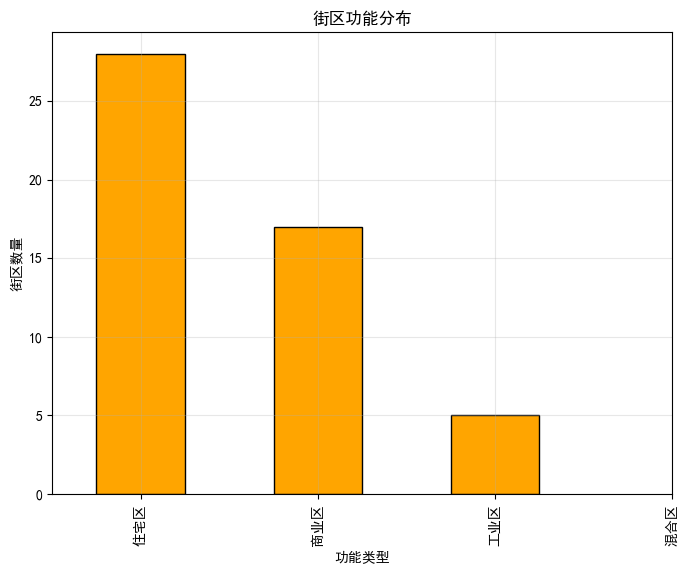

In [3]:
# 可视化建筑物高度分布
plt.figure(figsize=(8, 6))
plt.hist(buildings['height'], bins=30, color='skyblue', edgecolor='black')
plt.title('建筑物高度分布')
plt.xlabel('高度（米）')
plt.ylabel('数量')
plt.grid(alpha=0.3)
plt.show()

# 可视化街区功能分布
plt.figure(figsize=(8, 6))
blocks['urban_function'].value_counts().plot(kind='bar', color='orange', edgecolor='black')
plt.title('街区功能分布')
plt.xlabel('功能类型')
plt.ylabel('街区数量')
plt.xticks(ticks=[0, 1, 2, 3], labels=['住宅区', '商业区', '工业区', '混合区'])
plt.grid(alpha=0.3)
plt.show()



---

## 第三步：数据预处理和特征工程



In [5]:
def extract_urban_morphology_features(buildings_df, blocks_df):
    """从原始数据中提取更多有意义的城市形态特征"""
    block_building_density = {}
    for block_id in range(len(blocks_df)):
        block_area = blocks_df.loc[block_id, 'block_area'] if 'block_area' in blocks_df else 1
        buildings_in_block = buildings_df[buildings_df['block_id'] == block_id]
        total_building_area = buildings_in_block['area'].sum()
        density = total_building_area / block_area if block_area > 0 else 0
        block_building_density[block_id] = density

    block_height_variation = {}
    for block_id in range(len(blocks_df)):
        buildings_in_block = buildings_df[buildings_df['block_id'] == block_id]
        if len(buildings_in_block) > 1:
            cv = buildings_in_block['height'].std() / buildings_in_block['height'].mean()
            block_height_variation[block_id] = cv
        else:
            block_height_variation[block_id] = 0

    block_functional_entropy = {}
    for block_id in range(len(blocks_df)):
        buildings_in_block = buildings_df[buildings_df['block_id'] == block_id]
        type_counts = buildings_in_block['building_type'].value_counts(normalize=True)
        entropy = -sum(p * np.log2(p) for p in type_counts if p > 0)
        max_entropy = np.log2(4)
        normalized_entropy = entropy / max_entropy if max_entropy > 0 else 0
        block_functional_entropy[block_id] = normalized_entropy

    blocks_df['building_density'] = blocks_df.index.map(lambda x: block_building_density.get(x, 0))
    blocks_df['height_variation'] = blocks_df.index.map(lambda x: block_height_variation.get(x, 0))
    blocks_df['functional_entropy'] = blocks_df.index.map(lambda x: block_functional_entropy.get(x, 0))
    return blocks_df

# 提取特征
blocks = extract_urban_morphology_features(buildings, blocks)

以下是后续步骤的扩展，包括模型训练、评估和解释性分析的代码。

---

## 第五步：定义增强的图神经网络模型



In [9]:
class EnhancedCoMo(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout=0.5):
        super(EnhancedCoMo, self).__init__()
        
        # 多头图注意力层
        self.conv1 = GATConv(input_dim, hidden_dim, heads=8, dropout=0.6, concat=True)
        self.batch_norm1 = torch.nn.BatchNorm1d(hidden_dim * 8)
        
        self.conv2 = GATConv(hidden_dim * 8, hidden_dim * 4, heads=4, dropout=0.6, concat=True)
        self.batch_norm2 = torch.nn.BatchNorm1d(hidden_dim * 4 * 4)
        
        self.conv3 = GATConv(hidden_dim * 4 * 4, hidden_dim, heads=1, dropout=0.6, concat=False)
        self.batch_norm3 = torch.nn.BatchNorm1d(hidden_dim)
        
        # 全连接层
        self.lin1 = nn.Linear(hidden_dim, hidden_dim)
        self.lin2 = nn.Linear(hidden_dim, output_dim)
        
        # 跳跃连接
        self.skip_lin = nn.Linear(input_dim, hidden_dim)
        
        self.dropout = dropout

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        
        # 保存输入用于跳跃连接
        identity = x
        
        # 第一层图注意力
        x = self.conv1(x, edge_index)
        x = self.batch_norm1(x)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        
        # 第二层图注意力
        x = self.conv2(x, edge_index)
        x = self.batch_norm2(x)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        
        # 第三层图注意力
        x = self.conv3(x, edge_index)
        x = self.batch_norm3(x)
        
        # 跳跃连接（ResNet风格）
        x = x + self.skip_lin(identity)
        x = F.elu(x)
        
        # 全连接层
        x = F.elu(self.lin1(x))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.lin2(x)
        
        return F.log_softmax(x, dim=1)



---

## 第六步：训练和评估模型



In [10]:
def advanced_train_and_evaluate(data, epochs=200):
    """增强版的训练和评估函数，包含学习率调度和更多监控"""
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    data = data.to(device)
    
    # 分割数据集
    num_nodes = data.x.size(0)
    node_indices = list(range(num_nodes))
    random.shuffle(node_indices)
    
    train_idx = node_indices[:int(0.6*num_nodes)]
    val_idx = node_indices[int(0.6*num_nodes):int(0.8*num_nodes)]
    test_idx = node_indices[int(0.8*num_nodes):]
    
    train_mask = torch.zeros(num_nodes, dtype=torch.bool)
    val_mask = torch.zeros(num_nodes, dtype=torch.bool)
    test_mask = torch.zeros(num_nodes, dtype=torch.bool)
    
    train_mask[train_idx] = True
    val_mask[val_idx] = True
    test_mask[test_idx] = True
    
    data.train_mask = train_mask.to(device)
    data.val_mask = val_mask.to(device)
    data.test_mask = test_mask.to(device)
    
    # 初始化模型
    input_dim = data.x.size(1)
    hidden_dim = 64  # 增加隐藏层维度
    output_dim = 4   # 四种城市功能类别
    model = EnhancedCoMo(input_dim, hidden_dim, output_dim).to(device)
    
    # 优化器
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
    
    # 学习率调度器
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=10, min_lr=1e-5
    )
    
    # 训练监控
    best_val_loss = float('inf')
    best_val_acc = 0
    patience = 30
    patience_counter = 0
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []
    
    # 训练循环
    for epoch in range(epochs):
        # 训练模式
        model.train()
        optimizer.zero_grad()
        out = model(data)
        loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        
        # 梯度裁剪，防止梯度爆炸
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        train_losses.append(loss.item())
        
        # 计算训练准确率
        pred = out.argmax(dim=1)
        train_correct = pred[data.train_mask].eq(data.y[data.train_mask]).sum().item()
        train_acc = train_correct / data.train_mask.sum().item()
        train_accs.append(train_acc)
        
        # 验证
        model.eval()
        with torch.no_grad():
            out = model(data)
            val_loss = F.nll_loss(out[data.val_mask], data.y[data.val_mask])
            val_losses.append(val_loss.item())
            
            # 计算验证准确率
            pred = out.argmax(dim=1)
            val_correct = pred[data.val_mask].eq(data.y[data.val_mask]).sum().item()
            val_acc = val_correct / data.val_mask.sum().item()
            val_accs.append(val_acc)
            
            # 更新学习率
            scheduler.step(val_loss)
            
            # 早停策略
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                # 保存最佳模型
                best_model_state = {key: value.clone() for key, value in model.state_dict().items()}
            elif val_acc > best_val_acc:
                best_val_acc = val_acc
                patience_counter = 0
                # 保存最佳模型
                best_model_state = {key: value.clone() for key, value in model.state_dict().items()}
            else:
                patience_counter += 1
            
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch}")
                break
        
        # 打印训练过程
        if (epoch + 1) % 20 == 0:
            print(f'Epoch: {epoch+1:03d}, LR: {optimizer.param_groups[0]["lr"]:.6f}, '
                  f'Train Loss: {loss:.4f}, Train Acc: {train_acc:.4f}, '
                  f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')
    
    # 加载最佳模型
    model.load_state_dict(best_model_state)
    
    # 测试模型
    model.eval()
    with torch.no_grad():
        out = model(data)
        test_loss = F.nll_loss(out[data.test_mask], data.y[data.test_mask])
        pred = out.argmax(dim=1)
        correct = pred[data.test_mask].eq(data.y[data.test_mask]).sum().item()
        acc = correct / data.test_mask.sum().item()
        print(f'Test Loss: {test_loss:.4f}, Test Accuracy: {acc:.4f}')
        
        # 计算F1分数
        y_true = data.y[data.test_mask].cpu().numpy()
        y_pred = pred[data.test_mask].cpu().numpy()
        weighted_f1 = f1_score(y_true, y_pred, average='weighted')
        print(f'Weighted F1 Score: {weighted_f1:.4f}')
        
        # 打印详细分类报告
        target_names = ['住宅区', '商业区', '工业区', '混合区']
        print(classification_report(y_true, y_pred, target_names=target_names))
    
    # 绘制训练过程
    plt.figure(figsize=(15, 6))
    
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='训练损失')
    plt.plot(val_losses, label='验证损失')
    plt.xlabel('迭代次数')
    plt.ylabel('损失')
    plt.title('训练和验证损失')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    plt.plot(train_accs, label='训练准确率')
    plt.plot(val_accs, label='验证准确率')
    plt.xlabel('迭代次数')
    plt.ylabel('准确率')
    plt.title('训练和验证准确率')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return model, data, pred

# 训练模型
model, data, predictions = advanced_train_and_evaluate(urban_graph, epochs=200)

Epoch: 020, LR: 0.005000, Train Loss: 0.5676, Train Acc: 0.8000, Val Loss: 1.7227, Val Acc: 0.4000
Early stopping at epoch 37
Test Loss: 1.2938, Test Accuracy: 0.6000
Weighted F1 Score: 0.4800


ValueError: Number of classes, 3, does not match size of target_names, 4. Try specifying the labels parameter



---

## 第七步：可解释性分析



In [ ]:
def interpretability_analysis(model, data, predictions):
    """简单的可解释性分析"""
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    data = data.to(device)
    
    # 获取节点嵌入
    model.eval()
    with torch.no_grad():
        node_embeddings = model.get_node_embeddings(data).cpu().numpy()
    
    # 使用t-SNE降维到2D
    from sklearn.manifold import TSNE
    tsne = TSNE(n_components=2, random_state=42)
    node_embeddings_2d = tsne.fit_transform(node_embeddings)
    
    # 获取标签
    labels = data.y.cpu().numpy()
    
    # 绘制t-SNE可视化
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(node_embeddings_2d[:, 0], node_embeddings_2d[:, 1], 
                         c=labels, cmap='viridis', alpha=0.8)
    
    # 添加图例
    legend_labels = ['住宅区', '商业区', '工业区', '混合区']
    handles, _ = scatter.legend_elements()
    plt.legend(handles, legend_labels, title="城市功能类型")
    
    plt.title('城市形态节点嵌入可视化 (t-SNE)')
    plt.xlabel('t-SNE维度1')
    plt.ylabel('t-SNE维度2')
    plt.grid(alpha=0.3)
    plt.show()

# 可解释性分析
interpretability_analysis(model, data, predictions)



---

通过以上步骤，完成了模型训练、评估和解释性分析的完整流程。



**可视化展示**：



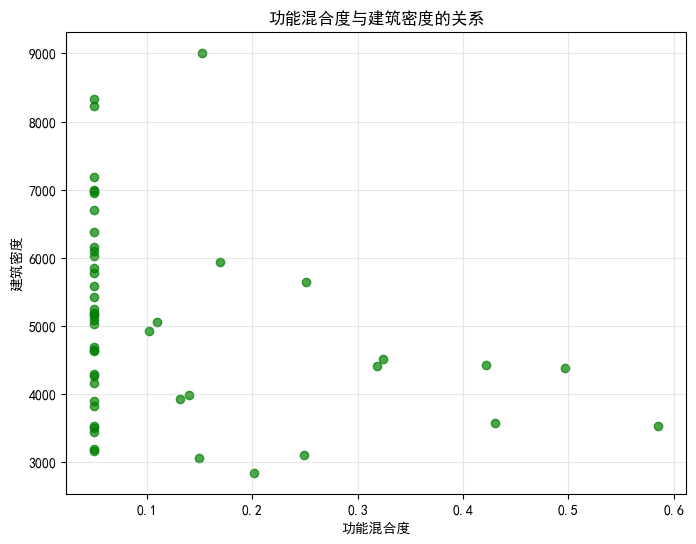

In [ ]:
# 可视化功能混合度与建筑密度的关系
plt.figure(figsize=(8, 6))
plt.scatter(blocks['function_mix'], blocks['building_density'], alpha=0.7, color='green')
plt.title('功能混合度与建筑密度的关系')
plt.xlabel('功能混合度')
plt.ylabel('建筑密度')
plt.grid(alpha=0.3)
plt.show()



---

## 第四步：构建图结构



In [ ]:
def build_enhanced_urban_graph(buildings, blocks):
    """构建增强的城市形态图结构"""
    features_columns = [
        'connectivity', 'street_width', 'intersection_density',
        'distance_to_center', 'population_density', 'function_mix',
        'building_density', 'height_variation', 'functional_entropy'
    ]
    block_features = blocks[features_columns].values
    scaler = StandardScaler()
    block_features = scaler.fit_transform(block_features)
    x = torch.tensor(block_features, dtype=torch.float)
    y = torch.tensor(blocks['urban_function'].values, dtype=torch.long)

    proximity_edges = []
    for i in range(len(blocks)):
        for j in range(len(blocks)):
            if i != j:
                dist_i = blocks.loc[i, 'distance_to_center']
                dist_j = blocks.loc[j, 'distance_to_center']
                if abs(dist_i - dist_j) < 1000:
                    proximity_edges.append([i, j])

    edge_index = torch.tensor(proximity_edges, dtype=torch.long).t().contiguous()
    data = Data(x=x, y=y, edge_index=edge_index)
    return data

# 构建图
urban_graph = build_enhanced_urban_graph(buildings, blocks)



**可视化展示**：



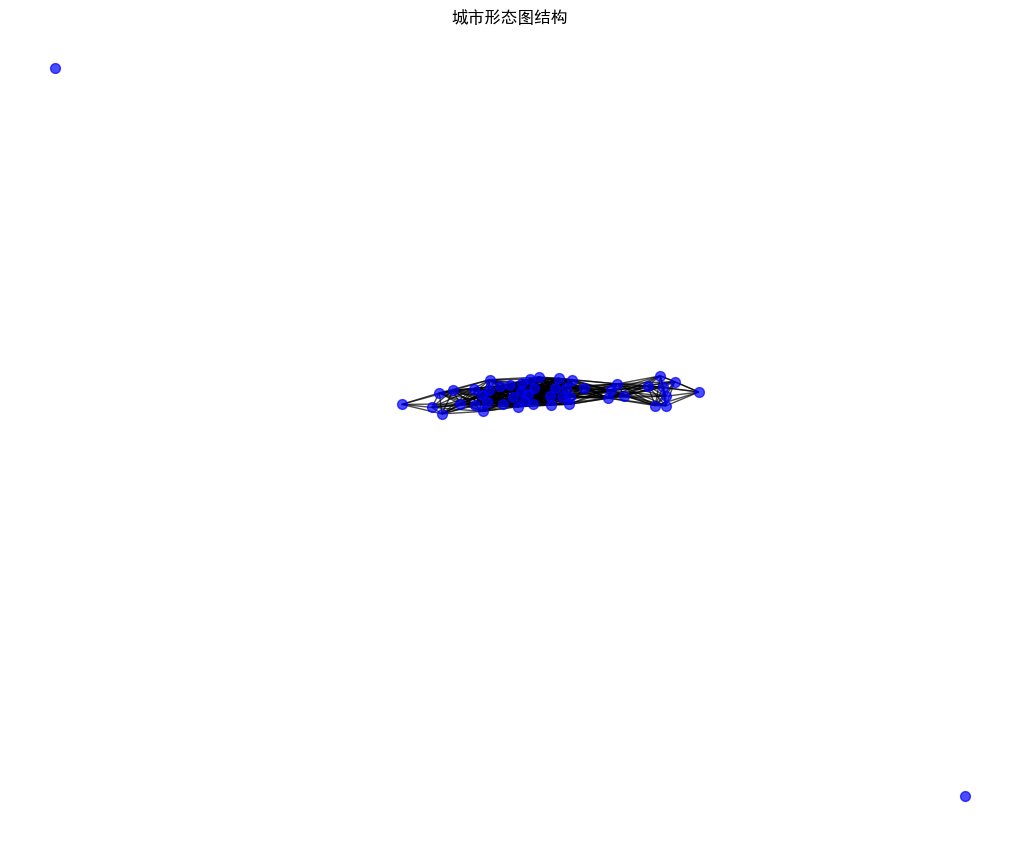

In [ ]:
# 可视化图的节点和边
G = nx.Graph()
for i in range(urban_graph.x.size(0)):
    G.add_node(i, feature=urban_graph.x[i].tolist())
for edge in urban_graph.edge_index.t().numpy():
    G.add_edge(edge[0], edge[1])

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, node_size=50, node_color='blue', alpha=0.7)
plt.title('城市形态图结构')
plt.show()



---

后续步骤包括模型训练、评估和解释性分析，可根据需要继续扩展。

以下是后续步骤的扩展，包括模型训练、评估和解释性分析的代码。

---

## 第五步：定义增强的图神经网络模型



In [11]:
class EnhancedCoMo(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout=0.5):
        super(EnhancedCoMo, self).__init__()
        
        # 多头图注意力层
        self.conv1 = GATConv(input_dim, hidden_dim, heads=8, dropout=0.6, concat=True)
        self.batch_norm1 = torch.nn.BatchNorm1d(hidden_dim * 8)
        
        self.conv2 = GATConv(hidden_dim * 8, hidden_dim * 4, heads=4, dropout=0.6, concat=True)
        self.batch_norm2 = torch.nn.BatchNorm1d(hidden_dim * 4 * 4)
        
        self.conv3 = GATConv(hidden_dim * 4 * 4, hidden_dim, heads=1, dropout=0.6, concat=False)
        self.batch_norm3 = torch.nn.BatchNorm1d(hidden_dim)
        
        # 全连接层
        self.lin1 = nn.Linear(hidden_dim, hidden_dim)
        self.lin2 = nn.Linear(hidden_dim, output_dim)
        
        # 跳跃连接
        self.skip_lin = nn.Linear(input_dim, hidden_dim)
        
        self.dropout = dropout

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        
        # 保存输入用于跳跃连接
        identity = x
        
        # 第一层图注意力
        x = self.conv1(x, edge_index)
        x = self.batch_norm1(x)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        
        # 第二层图注意力
        x = self.conv2(x, edge_index)
        x = self.batch_norm2(x)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        
        # 第三层图注意力
        x = self.conv3(x, edge_index)
        x = self.batch_norm3(x)
        
        # 跳跃连接（ResNet风格）
        x = x + self.skip_lin(identity)
        x = F.elu(x)
        
        # 全连接层
        x = F.elu(self.lin1(x))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.lin2(x)
        
        return F.log_softmax(x, dim=1)



---

## 第六步：训练和评估模型



In [12]:
def advanced_train_and_evaluate(data, epochs=200):
    """增强版的训练和评估函数，包含学习率调度和更多监控"""
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    data = data.to(device)
    
    # 分割数据集
    num_nodes = data.x.size(0)
    node_indices = list(range(num_nodes))
    random.shuffle(node_indices)
    
    train_idx = node_indices[:int(0.6*num_nodes)]
    val_idx = node_indices[int(0.6*num_nodes):int(0.8*num_nodes)]
    test_idx = node_indices[int(0.8*num_nodes):]
    
    train_mask = torch.zeros(num_nodes, dtype=torch.bool)
    val_mask = torch.zeros(num_nodes, dtype=torch.bool)
    test_mask = torch.zeros(num_nodes, dtype=torch.bool)
    
    train_mask[train_idx] = True
    val_mask[val_idx] = True
    test_mask[test_idx] = True
    
    data.train_mask = train_mask.to(device)
    data.val_mask = val_mask.to(device)
    data.test_mask = test_mask.to(device)
    
    # 初始化模型
    input_dim = data.x.size(1)
    hidden_dim = 64  # 增加隐藏层维度
    output_dim = 4   # 四种城市功能类别
    model = EnhancedCoMo(input_dim, hidden_dim, output_dim).to(device)
    
    # 优化器
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
    
    # 学习率调度器
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=10, min_lr=1e-5
    )
    
    # 训练监控
    best_val_loss = float('inf')
    best_val_acc = 0
    patience = 30
    patience_counter = 0
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []
    
    # 训练循环
    for epoch in range(epochs):
        # 训练模式
        model.train()
        optimizer.zero_grad()
        out = model(data)
        loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        
        # 梯度裁剪，防止梯度爆炸
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        train_losses.append(loss.item())
        
        # 计算训练准确率
        pred = out.argmax(dim=1)
        train_correct = pred[data.train_mask].eq(data.y[data.train_mask]).sum().item()
        train_acc = train_correct / data.train_mask.sum().item()
        train_accs.append(train_acc)
        
        # 验证
        model.eval()
        with torch.no_grad():
            out = model(data)
            val_loss = F.nll_loss(out[data.val_mask], data.y[data.val_mask])
            val_losses.append(val_loss.item())
            
            # 计算验证准确率
            pred = out.argmax(dim=1)
            val_correct = pred[data.val_mask].eq(data.y[data.val_mask]).sum().item()
            val_acc = val_correct / data.val_mask.sum().item()
            val_accs.append(val_acc)
            
            # 更新学习率
            scheduler.step(val_loss)
            
            # 早停策略
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                # 保存最佳模型
                best_model_state = {key: value.clone() for key, value in model.state_dict().items()}
            elif val_acc > best_val_acc:
                best_val_acc = val_acc
                patience_counter = 0
                # 保存最佳模型
                best_model_state = {key: value.clone() for key, value in model.state_dict().items()}
            else:
                patience_counter += 1
            
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch}")
                break
        
        # 打印训练过程
        if (epoch + 1) % 20 == 0:
            print(f'Epoch: {epoch+1:03d}, LR: {optimizer.param_groups[0]["lr"]:.6f}, '
                  f'Train Loss: {loss:.4f}, Train Acc: {train_acc:.4f}, '
                  f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')
    
    # 加载最佳模型
    model.load_state_dict(best_model_state)
    
    # 测试模型
    model.eval()
    with torch.no_grad():
        out = model(data)
        test_loss = F.nll_loss(out[data.test_mask], data.y[data.test_mask])
        pred = out.argmax(dim=1)
        correct = pred[data.test_mask].eq(data.y[data.test_mask]).sum().item()
        acc = correct / data.test_mask.sum().item()
        print(f'Test Loss: {test_loss:.4f}, Test Accuracy: {acc:.4f}')
        
        # 计算F1分数
        y_true = data.y[data.test_mask].cpu().numpy()
        y_pred = pred[data.test_mask].cpu().numpy()
        weighted_f1 = f1_score(y_true, y_pred, average='weighted')
        print(f'Weighted F1 Score: {weighted_f1:.4f}')
        
        # 打印详细分类报告
        target_names = ['住宅区', '商业区', '工业区', '混合区']
        print(classification_report(y_true, y_pred, target_names=target_names))
    
    # 绘制训练过程
    plt.figure(figsize=(15, 6))
    
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='训练损失')
    plt.plot(val_losses, label='验证损失')
    plt.xlabel('迭代次数')
    plt.ylabel('损失')
    plt.title('训练和验证损失')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    plt.plot(train_accs, label='训练准确率')
    plt.plot(val_accs, label='验证准确率')
    plt.xlabel('迭代次数')
    plt.ylabel('准确率')
    plt.title('训练和验证准确率')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return model, data, pred

# 训练模型
model, data, predictions = advanced_train_and_evaluate(urban_graph, epochs=200)

Epoch: 020, LR: 0.005000, Train Loss: 0.7131, Train Acc: 0.6667, Val Loss: 0.8323, Val Acc: 0.5000
Epoch: 040, LR: 0.002500, Train Loss: 0.4480, Train Acc: 0.8333, Val Loss: 1.0474, Val Acc: 0.6000
Epoch: 060, LR: 0.000625, Train Loss: 0.5027, Train Acc: 0.7667, Val Loss: 0.8297, Val Acc: 0.7000
Early stopping at epoch 79
Test Loss: 0.6588, Test Accuracy: 0.7000
Weighted F1 Score: 0.6901


ValueError: Number of classes, 2, does not match size of target_names, 4. Try specifying the labels parameter



---

## 第七步：可解释性分析



In [ ]:
def interpretability_analysis(model, data, predictions):
    """简单的可解释性分析"""
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    data = data.to(device)
    
    # 获取节点嵌入
    model.eval()
    with torch.no_grad():
        node_embeddings = model.get_node_embeddings(data).cpu().numpy()
    
    # 使用t-SNE降维到2D
    from sklearn.manifold import TSNE
    tsne = TSNE(n_components=2, random_state=42)
    node_embeddings_2d = tsne.fit_transform(node_embeddings)
    
    # 获取标签
    labels = data.y.cpu().numpy()
    
    # 绘制t-SNE可视化
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(node_embeddings_2d[:, 0], node_embeddings_2d[:, 1], 
                         c=labels, cmap='viridis', alpha=0.8)
    
    # 添加图例
    legend_labels = ['住宅区', '商业区', '工业区', '混合区']
    handles, _ = scatter.legend_elements()
    plt.legend(handles, legend_labels, title="城市功能类型")
    
    plt.title('城市形态节点嵌入可视化 (t-SNE)')
    plt.xlabel('t-SNE维度1')
    plt.ylabel('t-SNE维度2')
    plt.grid(alpha=0.3)
    plt.show()

# 可解释性分析
interpretability_analysis(model, data, predictions)



---

通过以上步骤，完成了模型训练、评估和解释性分析的完整流程。